## Transformer Hawkes Process: Architecture reproduction

<ins> Source <ins>: 

- arxiv.org/abs/2002.09291

<ins>Inputs<ins>:
- $\{ (t_i, k_i) \}_{i=1}^L$ with $L$ sequence length, $t_i$ event times increasing, $k_i$ event types taking integral values in [1,K]. I will call T, Y the sequence of times and Y that of event types.

<ins> Architecture for structuring the past<ins>:

- Event times encoding:
    - From $T$, build $Z$ defined as $[Z(t_j)]_i := \cos{(\frac{t_j}{1000^{\frac{i-1}{M}}})}$ if i is odd, $\sin{(\frac{t_j}{1000^{\frac{i}{M}}})}$ if i is even.
    - $M$ is the designed encoding dimension for our timestamps: $Z$ will have dimension $M \times L$.
- Event types encoding:
    - We will train an embedding matrix $U$ of dimension $M \times K$ such that $UY$ will have dimension $M \times L$.

These choices pre-supposed that we consider $Y$ and $T$ to be of dimensions $K \times L$ and $1 \times L$.

- Positional encoding:
    - These encodings are then combined into $X = (UY + Z)^T$, with dimension $L \times M$.

- Attention layer:
    - Encoded $X$ is then fed into a MultiHeadAttention with $H$ heads. 
    - We mask the attention computation: $Q(j,j+1:) = -\infty$, to avoid breaking causality chain.
    - The $H$ heads outputs are concatenated with a linear layer W^O: the output is $S = [S_1,\cdots,S_H] W^O$.

- Hidden representation:
    - The attention outputs $S$ are fed in a MLP $H = ReLU(SW_1^{FC} + b_1)W_2^{FC} + b_2$, $H(j,:) = h(t_j)$.

<ins> Conditional intensity modeling: <ins>

- With $h(t_j)$ representing the filtration $\mathcal{H}_t$ of the point process, seek $\lambda_k(t | \mathcal{H}_t) = SoftPlus_{\beta_k}(\alpha_k \frac{t-t_j}{t_j} + w_k^T h(t_j) + b_k)$ and total conditional intensity $\lambda(t | \mathcal{H}_t) = \sum_{k=1}^K \lambda_k(t | \mathcal{H}_t)$.

In [17]:
from thp import TransformerHawkesProcess
from loss import LogLikelihoodPP
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import LambdaLR
import torch.nn as nn
import torch

In [10]:
import torch.nn.functional as F

def poisson_generator(N=1000, M=1000, K=10):
    exp_dist = torch.distributions.Exponential(rate=1.0)

    event_times = exp_dist.sample(sample_shape=(N, M)).cumsum(dim=1)

    # Labels in {1, ..., K}; 0 is reserved for padding.
    event_type_labels = torch.randint(
        low=1,
        high=K + 1,
        size=(N, M),
    )

    # One-hot with padding column included: [N, M, K + 1]
    event_types_padded = F.one_hot(
        event_type_labels,
        num_classes=K + 1,
    ).float()

    # Drop padding column, so final event_types is [N, M, K]
    event_types = event_types_padded[..., 1:]

    return event_times, event_types

In [12]:
model = TransformerHawkesProcess(embed_dim=16, event_dim=10, key_dim=16, value_dim=16, mlp_depth=64, state_dim=16, n_heads=2, time_base=500.0)

In [15]:
optimizer = torch.optim.AdamW(params=model.parameters(), lr=1e-2, weight_decay=5 * 1e-2)

In [23]:
batch_size = 128
num_epochs = 1000
max_grad_norm = 1.0

N=batch_size * 64
M=100
K=10

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

event_times, event_types = poisson_generator(N=N, M=M, K=K)
dataset = TensorDataset(event_times, event_types)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

model = model.to(device)
criterion = LogLikelihoodPP().to(device)
history = []
warmup = LambdaLR(optimizer, lr_lambda=lambda s: min(1.0, s / 1000))

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total_predicted_events = 0
    if epoch % 5 == 0:
        event_times, event_types = poisson_generator(N=N, M=M, K=K)
        dataset = TensorDataset(event_times, event_types)
        train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
    for batch_times, batch_types in train_loader:
        batch_times = batch_times.to(device)
        batch_types = batch_types.to(device)

        optimizer.zero_grad(set_to_none=True)
        intensities = model(
            times=batch_times,
            event_times=batch_times,
            event_types=batch_types,
        )
        loss = criterion(batch_times, intensities, batch_types)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        warmup.step()

        total_loss += loss.item()
        total_predicted_events += batch_times.size(0) * (batch_times.size(1) - 1)

    avg_nll = total_loss / total_predicted_events
    history.append(avg_nll)
    print(f"epoch {epoch + 1:02d} | nll/event {avg_nll:.4f}")

epoch 01 | nll/event 3.2385
epoch 02 | nll/event 3.2372
epoch 03 | nll/event 3.2371
epoch 04 | nll/event 3.2371
epoch 05 | nll/event 3.2369
epoch 06 | nll/event 3.2365
epoch 07 | nll/event 3.2361
epoch 08 | nll/event 3.2359
epoch 09 | nll/event 3.2358
epoch 10 | nll/event 3.2359
epoch 11 | nll/event 3.2388
epoch 12 | nll/event 3.2389
epoch 13 | nll/event 3.2390
epoch 14 | nll/event 3.2390
epoch 15 | nll/event 3.2389
epoch 16 | nll/event 3.2352
epoch 17 | nll/event 3.2352
epoch 18 | nll/event 3.2346
epoch 19 | nll/event 3.2352
epoch 20 | nll/event 3.2346
epoch 21 | nll/event 3.2355
epoch 22 | nll/event 3.2353
epoch 23 | nll/event 3.2354
epoch 24 | nll/event 3.2351
epoch 25 | nll/event 3.2350
epoch 26 | nll/event 3.2351
epoch 27 | nll/event 3.2346
epoch 28 | nll/event 3.2346
epoch 29 | nll/event 3.2342
epoch 30 | nll/event 3.2345
epoch 31 | nll/event 3.2332
epoch 32 | nll/event 3.2328
epoch 33 | nll/event 3.2329
epoch 34 | nll/event 3.2329
epoch 35 | nll/event 3.2331
epoch 36 | nll/event

KeyboardInterrupt: 

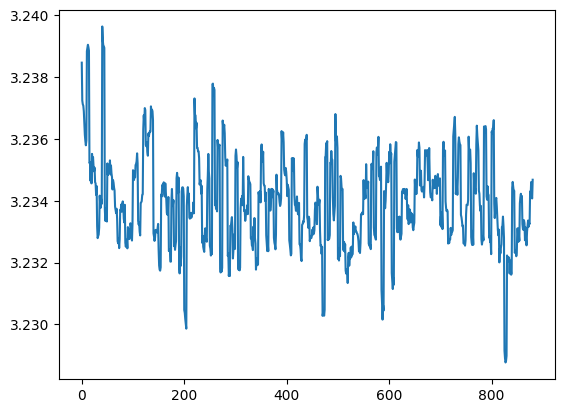

In [24]:
import matplotlib.pyplot as plt
plt.plot(history)